# SVM (RBF) Baseline Model
**Module:** IT3051 - Fundamentals of Data Mining  
**Project:** Next-Year PM2.5 Air-Quality Risk Classification  
**Model:** Support Vector Machine (RBF Kernel)  
**Purpose:** Baseline model development and validation — Pabodha's model

This notebook follows the existing project methodology: chronological splitting, train-only preprocessing fit, validation evaluation, and an untouched test set. Hyperparameter tuning and imbalance optimization are intentionally left for later notebooks.

In [4]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

project_root = Path.cwd().parent

# Handle cases where VS Code starts the notebook from a different working directory
if not (project_root / "data" / "processed").exists():
    current = Path.cwd().resolve()

    for parent in [current] + list(current.parents):
        if (parent / "data" / "processed").exists() and (parent / "src").exists():
            project_root = parent
            break
        
print("Imports loaded successfully.")
print("Project root:", project_root)

Imports loaded successfully.
Project root: c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main


## 1. Load Chronological Split Datasets
Uses the same files created by `07_make_dataset.ipynb`: training up to 2012, validation 2013–2014, and test 2015 onward.

In [5]:
processed_dir = project_root / "data" / "processed"
train_path = processed_dir / "train_data.csv"
validation_path = processed_dir / "validation_data.csv"
test_path = processed_dir / "test_data.csv"

for path in [train_path, validation_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}\nRun 07_make_dataset.ipynb first.")

identifier_types = {"site_id":"string","state_code":"string","county_code":"string","site_num":"string"}
train_df = pd.read_csv(train_path, dtype=identifier_types, low_memory=False)
validation_df = pd.read_csv(validation_path, dtype=identifier_types, low_memory=False)
test_df = pd.read_csv(test_path, dtype=identifier_types, low_memory=False)
print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 2. Confirm the Chronological Split

In [6]:
for name, dataset in [("Training",train_df),("Validation",validation_df),("Test",test_df)]:
    print(f"{name}: {dataset['year'].min()} - {dataset['year'].max()} ({len(dataset)} rows)")

Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

In [7]:
train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(validation_df)
test_prepared = prepare_base_dataframe(test_df)
print("Base preprocessing completed.")

Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.


## 4. Separate Features and Target

In [8]:
X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True)*100).round(2))

Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val: (1783, 33) | y_val: (1783,)
X_test: (1561, 33) | y_test: (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6846
Unhealthy for Sensitive Groups    5050
Unhealthy                         1202
Good                                53
Very Unhealthy                      40
Name: count, dtype: int64

Training target percentages:
pm25_risk_category_next_year
Moderate                          51.90
Unhealthy for Sensitive Groups    38.28
Unhealthy                          9.11
Good          

## 5. Build and Fit the Preprocessor
The transformer is fitted only on `X_train`. Scaling is important for the distance-based RBF kernel.

In [9]:
preprocessor = build_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Numerical features: 29
Categorical features: 4
Processed training shape: (13191, 2154)
Processed validation shape: (1783, 2154)
Processed test shape: (1561, 2154)


## 6. Train Baseline SVM (RBF)
Uses baseline `C=1.0` and `gamma="scale"`. No SMOTE or class weighting is used here.

In [10]:
svm_rbf_baseline = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf_baseline.fit(X_train_processed, y_train)
print("Baseline SVM (RBF) training completed.")

Baseline SVM (RBF) training completed.


## 7. Evaluate on the Original Validation Set

In [11]:
y_val_pred = svm_rbf_baseline.predict(X_val_processed)
validation_accuracy = accuracy_score(y_val, y_val_pred)
validation_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print("SVM (RBF) BASELINE - VALIDATION RESULTS")
print("="*50)
print(f"Accuracy : {validation_accuracy:.6f}")
print(f"Macro F1 : {validation_macro_f1:.6f}")

SVM (RBF) BASELINE - VALIDATION RESULTS
Accuracy : 0.753786
Macro F1 : 0.297148


In [12]:
classification_report_df = pd.DataFrame(
    classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
).T
classification_report_df

,precision,recall,f1-score,support
Good,0.000000,0.000000,0.000000,5.000000
Moderate,0.775916,0.980392,0.866251,1275.000000
Unhealthy,0.550725,0.287879,0.378109,132.000000
Unhealthy for Sensitive Groups,0.543689,0.155125,0.241379,361.000000
Very Unhealthy,0.000000,0.000000,0.000000,10.000000
accuracy,0.753786,0.753786,0.753786,0.753786
macro avg,0.374066,0.284679,0.297148,1783.000000
weighted avg,0.705698,0.753786,0.696309,1783.000000


## 8. Validation Confusion Matrix

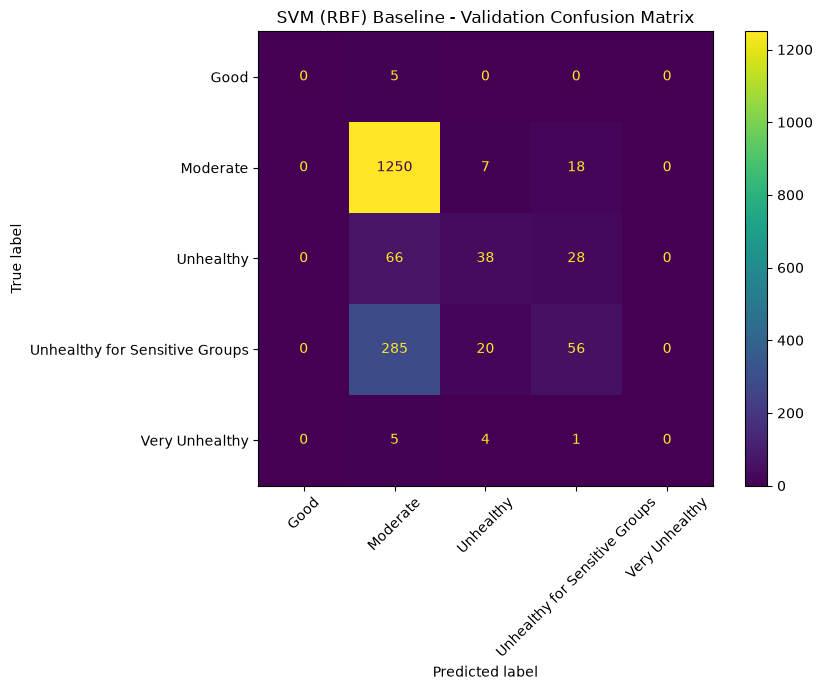

Saved: c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\pictures\svm_rbf_baseline_confusion_matrix.png


In [13]:
pictures_dir = project_root / "reports" / "pictures"
pictures_dir.mkdir(parents=True, exist_ok=True)
labels = sorted(pd.Series(y_val).dropna().unique())
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, labels=labels, xticks_rotation=45, ax=ax)
ax.set_title("SVM (RBF) Baseline - Validation Confusion Matrix")
plt.tight_layout()
confusion_matrix_path = pictures_dir / "svm_rbf_baseline_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", confusion_matrix_path)

## 9. Validation Metrics Plot

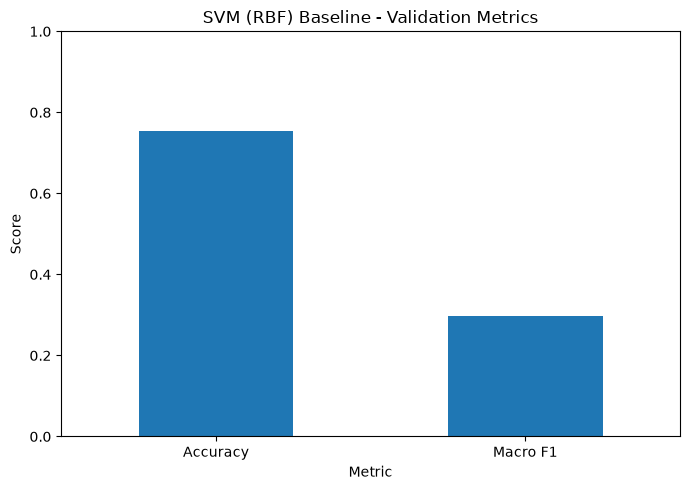

Saved: c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\pictures\svm_rbf_baseline_metrics.png


In [14]:
metrics_df = pd.DataFrame({"Metric":["Accuracy","Macro F1"],"Score":[validation_accuracy,validation_macro_f1]})
ax = metrics_df.plot(x="Metric",y="Score",kind="bar",legend=False,figsize=(7,5),rot=0)
ax.set_title("SVM (RBF) Baseline - Validation Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0,1)
plt.tight_layout()
metrics_plot_path = pictures_dir / "svm_rbf_baseline_metrics.png"
plt.savefig(metrics_plot_path,dpi=300,bbox_inches="tight")
plt.show()
print("Saved:", metrics_plot_path)

## 10. Save Baseline Results

In [15]:
results_dir = project_root / "reports" / "model_results"
results_dir.mkdir(parents=True, exist_ok=True)
summary_df = pd.DataFrame([{
    "model":"SVM (RBF) Baseline","kernel":"rbf","C":1.0,"gamma":"scale",
    "validation_accuracy":validation_accuracy,"validation_macro_f1":validation_macro_f1
}])
results_path = results_dir / "svm_rbf_baseline_results.csv"
report_path = results_dir / "svm_rbf_baseline_classification_report.csv"
summary_df.to_csv(results_path,index=False)
classification_report_df.to_csv(report_path)
print("Saved:",results_path)
print("Saved:",report_path)

Saved: c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\model_results\svm_rbf_baseline_results.csv
Saved: c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\model_results\svm_rbf_baseline_classification_report.csv


## 11. Output Check

In [16]:
for path in [results_path,report_path,confusion_matrix_path,metrics_plot_path]:
    print(("OK" if path.exists() else "MISSING"), "-", path)
print("\nIMPORTANT: Preprocessing was fitted only on training data.")
print("IMPORTANT: No SMOTE or class weighting was used in this baseline.")
print("IMPORTANT: Test labels were not used for model selection.")

OK - c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\model_results\svm_rbf_baseline_results.csv
OK - c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\model_results\svm_rbf_baseline_classification_report.csv
OK - c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\pictures\svm_rbf_baseline_confusion_matrix.png
OK - c:\Users\DELL\OneDrive\Desktop\FDM-Mini-Project\FDM-Mini-Project-main\reports\pictures\svm_rbf_baseline_metrics.png

IMPORTANT: Preprocessing was fitted only on training data.
IMPORTANT: No SMOTE or class weighting was used in this baseline.
IMPORTANT: Test labels were not used for model selection.
